In [1]:
# Common Python file that imports all the necessary libraries and common variables used

from setup import *

# Common link directory to save figures
out_path = "output/p2"
os.makedirs(out_path, exist_ok=True)

## Encoder Model

In [2]:
class Encoder(nn.Module):
    def __init__(self, inp_size, hidden_size):
        super(Encoder, self).__init__()

        self.input_size = inp_size
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(self.input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_tensor, hidden_state):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        output, hidden_state = self.gru(embedded, hidden_state)

        return output, hidden_state
    
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

## Decoder Model with Attention

In [3]:
class AttnDecoder(nn.Module):
    def __init__(self, hidden_size, out_size, max_length=100, dropout_p=0.1):
        super(AttnDecoder, self).__init__()

        self.hidden_size = hidden_size
        self.output_size = out_size
        self.drouput_p = dropout_p
        self.max_length = max_length

        self.embedding = nn.Embedding(out_size, hidden_size)

        # Added parts for attention
        self.attn = nn.Linear(self.hidden_size * 2, self.max_length)
        self.attn_combine = nn.Linear(self.hidden_size * 2, self.hidden_size)
        self.drouput = nn.Dropout()


        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, out_size)
    
    def forward(self, input_tensor, hidden_state, encoder_outputs):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        embedded = self.drouput(embedded)

        # Calculating weights with attentionn
        attn_weights = torch.softmax(self.attn(torch.cat((embedded[0], hidden_state[0]), 1)), dim=1)

        # Getting context from encoder outputs
        attn_applied = torch.bmm(attn_weights.unsqueeze(0), encoder_outputs.unsqueeze(0))

        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = self.attn_combine(output).unsqueeze(0)
        output = torch.relu(output)
        output, hidden_state = self.gru(output, hidden_state)
        output = torch.log_softmax(self.out(output[0]), dim=1)

        return output, hidden_state, attn_weights
    
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

## Helper Functions

In [4]:
def forward_pass_attn(input_tensor, target_tensor, encoder, decoder, criterion):
    encoder_hidden = encoder.initHidden()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)
    loss = 0

    # Encoding

    # Collecting outputs for attention
    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    # Encoding loop
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei].unsqueeze(0), encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    # Decoding
    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden

    for di in range(target_length):
        decoder_output, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs)
        _, topi = decoder_output.topk(1)
        decoder_input = topi.squeeze().detach()

        loss += criterion(decoder_output, target_tensor[di].unsqueeze(0))

        if decoder_input.item() == EOS_token:
            break

    return loss / target_length

In [ ]:
def train_attn(input_tensor, target_tensor, encoder, decoder, encoder_optim, decoder_optim, criterion):
    encoder_optim.zero_grad()
    decoder_optim.zero_grad()

    loss = forward_pass_attn(input_tensor, target_tensor, encoder, decoder, criterion)
    loss.backward()

    encoder_optim.step()
    decoder_optim.step()

    return loss.item()

In [6]:
def plot_attention_map(encoder, decoder, input_string, path):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        # Converting input string to tensor
        input_tensor = torch.tensor([chars_to_idx[char] for char in input_string] + [EOS_token], dtype=torch.long, device=device)
        input_length = input_tensor.size(0)
        
        encoder_hidden = encoder.initHidden()
        encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

        # Encoding
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei].unsqueeze(0), encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        # Decoding
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        predicted_chars = []
        attention_matrix = []

        for di in range(max_length):
            decoder_output, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs)
            _, topi = decoder_output.topk(1)
            idx_pred = topi.item()

            if idx_pred == EOS_token:
                break

            predicted_chars.append(idx_to_chars[idx_pred])
            attention_matrix.append(attn_weights.squeeze(0).squeeze(0).cpu().numpy())
            decoder_input = topi.squeeze().detach()

        predicted_string = ''.join(predicted_chars)

        attention_matrix = np.array(attention_matrix)
        attention_matrix = attention_matrix[:, :input_length]

        input_chars = list(input_string) + ['EOS']
        output_chars = predicted_chars

        # Plotting the map
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(attention_matrix, cmap='Blues', aspect='auto')

        ax.set_xticks(range(len(input_chars)))
        ax.set_yticks(range(len(output_chars)))
        ax.set_xticklabels(input_chars, rotation=90, fontsize=9)
        ax.set_yticklabels(output_chars, fontsize=9)

        plt.xlabel('Input (English)')
        plt.ylabel('Output (French)')
        plt.title(f'Attention Map\nInput: "{input_string}"\tPredicted: "{predicted_string}"')

        plt.colorbar(im)
        plt.tight_layout()

        os.makedirs(os.path.dirname(path), exist_ok=True)
        plt.savefig(path, dpi=200, bbox_inches='tight')
        plt.show()

        print(f'Input: {input_string}')
        print(f'Predicted: {predicted_string}')

In [7]:
# Taken from sequence2sequence.py
def eval_show_eg_attn(encoder, decoder, n_eg=5):
    encoder.eval()
    decoder.eval()

    exact_matches = 0
    total_bleu_score = 0.0
    chencherry = SmoothingFunction()

    print(f'\n')
    print('='*70)
    print(f'Generating Validation Examples')
    print('='*70)

    with torch.no_grad():
        for i, (input_tensor, target_tensor) in enumerate(val_loader):
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()
            input_length = input_tensor.size(0)
            encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

            # Passing through encoder
            for ei in range(input_length):
                encoder_output, encoder_hidden = encoder(input_tensor[ei].unsqueeze(0), encoder_hidden)
                encoder_outputs[ei] = encoder_output[0, 0]
            
            # Setting up the decoder
            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden
            predicted_idx = []

            # Range is extended to account for the larger sentences
            for di in range(100):
                decoder_output, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs)
                _, topi = decoder_output.topk(1)
                
                idx_pred = topi.item()
                predicted_idx.append(idx_pred)
                
                decoder_input = topi.squeeze().detach()

                if idx_pred == EOS_token:
                    break

            input_string = ''.join([idx_to_chars[index.item()] for index in input_tensor if index.item() not in (SOS_token, EOS_token)])
            target_string = ''.join([idx_to_chars[index.item()] for index in target_tensor if index.item() not in (SOS_token, EOS_token)])
            predicted_string = ''.join([idx_to_chars[index] for index in predicted_idx if index not in (SOS_token, EOS_token)])

            # Metric 1: Tradition Sequence Accuracy
            if predicted_string == target_string:
                exact_matches += 1
            
            # Metric 2: BLUE Score
            ref_tokens = [list(target_string)]
            candidate_tokens = list(predicted_string)

            bleu = sentence_bleu(ref_tokens, candidate_tokens, smoothing_function=chencherry.method1)
            total_bleu_score += bleu

            if i < n_eg:
                match_status = "PASS" if predicted_string == target_string else "FAIL"
                print(f'Input: {input_string:<12} | Target: {target_string:<12} | Predicted: {predicted_string:<12} | Match: {match_status:<4} | BLEU: {bleu:.4f}')
        
        total_samples = len(val_loader)
        final_acc = exact_matches / total_samples
        avg_bleu = total_bleu_score / total_samples

        print('='*70)
        print(f'Final Metrics across Dataset:')
        print(f'\nTraditional Exact-Match Accuracy: {final_acc * 100:.2f}% ({exact_matches} / {total_samples} samples)')
        print(f'\nAverage Validation BLEU Score: {avg_bleu:.4f}')
        print('='*70)

## Problem 2

Starting Training
Epoch 00 | Train Loss: 2.9199 | Val Loss: 2.6612
Epoch 05 | Train Loss: 2.4498 | Val Loss: 2.6433
Epoch 10 | Train Loss: 2.3544 | Val Loss: 2.4044
Epoch 15 | Train Loss: 2.2704 | Val Loss: 2.4120
Epoch 20 | Train Loss: 2.1934 | Val Loss: 2.4645
Epoch 25 | Train Loss: 2.0671 | Val Loss: 2.5231
Epoch 30 | Train Loss: 2.0209 | Val Loss: 2.4306
Epoch 35 | Train Loss: 1.9557 | Val Loss: 2.7165
Epoch 40 | Train Loss: 1.8711 | Val Loss: 2.5908
Epoch 45 | Train Loss: 1.8245 | Val Loss: 2.7366


Generating Validation Examples
Input: He replies to all customer emails immediately | Target: Il répond immédiatement à tous les e-mails des clients | Predicted: Il ailant sonnnnnnnnnnn  n               nininaininin | Match: FAIL | BLEU: 0.0502
Input: We work in the office | Target: Nous travaillons au bureau | Predicted: Nous chans    rrrrrrrrnr | Match: FAIL | BLEU: 0.2006
Input: I want a large slice of chocolate cake | Target: Je veux une grande part de gâteau au chocolat | Predicte

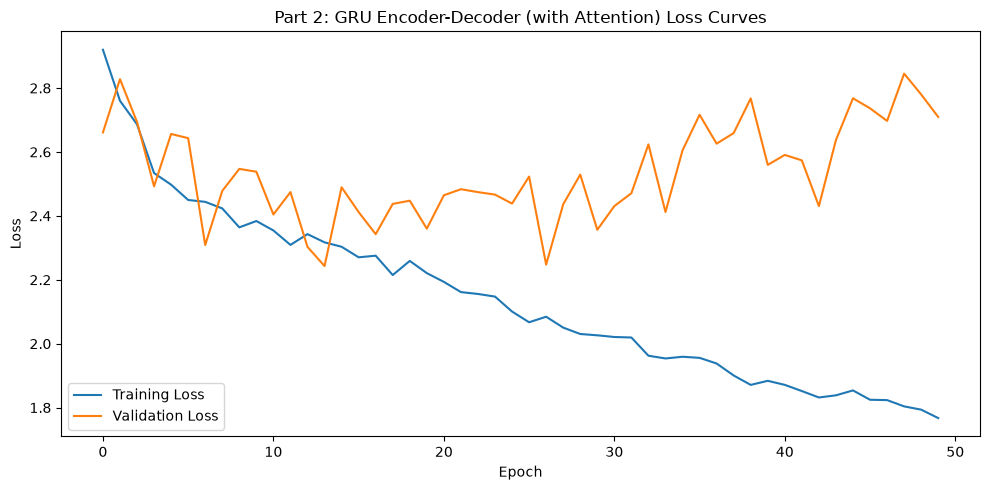

/tmp/ipykernel_3190563/3330002915.py:59: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3190563/3330002915.py:62: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=200, bbox_inches='tight')
/home/govind/Documents/introToDL/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


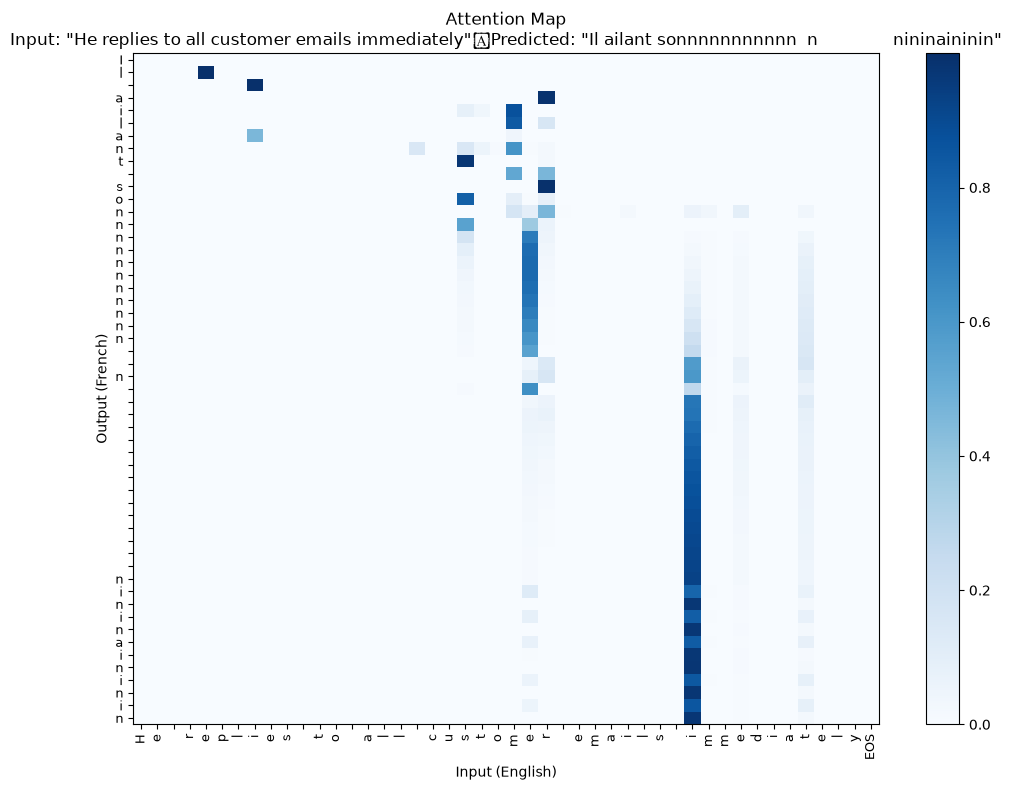

/tmp/ipykernel_3190563/3330002915.py:59: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3190563/3330002915.py:62: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=200, bbox_inches='tight')


Input: He replies to all customer emails immediately
Predicted: Il ailant sonnnnnnnnnnn  n               nininaininin


/home/govind/Documents/introToDL/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


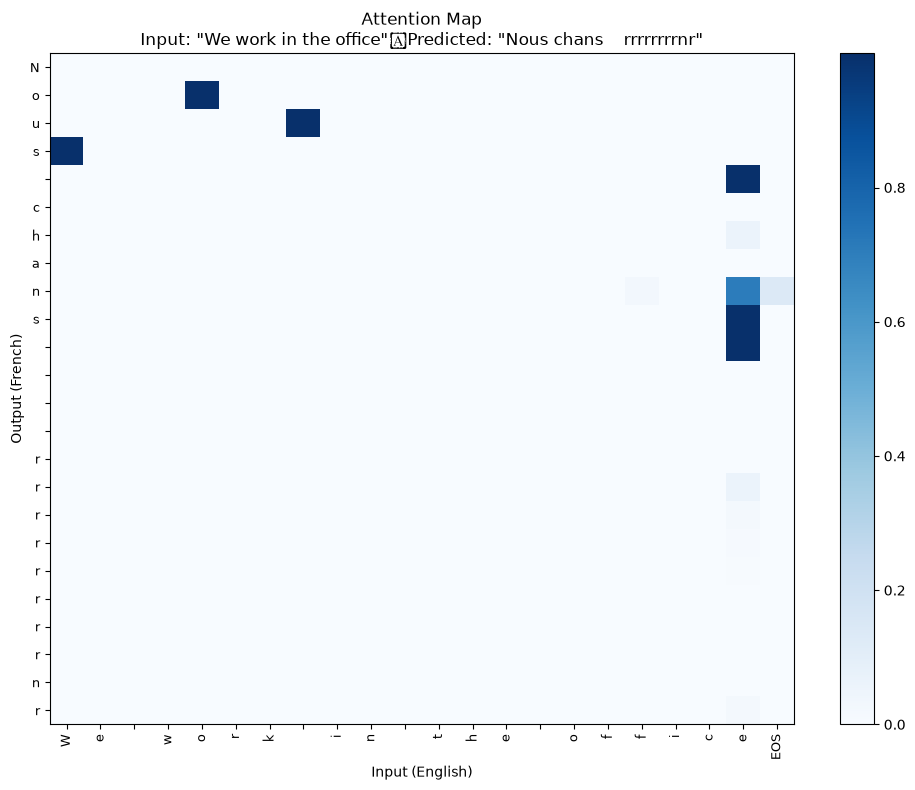

/tmp/ipykernel_3190563/3330002915.py:59: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3190563/3330002915.py:62: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=200, bbox_inches='tight')


Input: We work in the office
Predicted: Nous chans    rrrrrrrrnr


/home/govind/Documents/introToDL/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


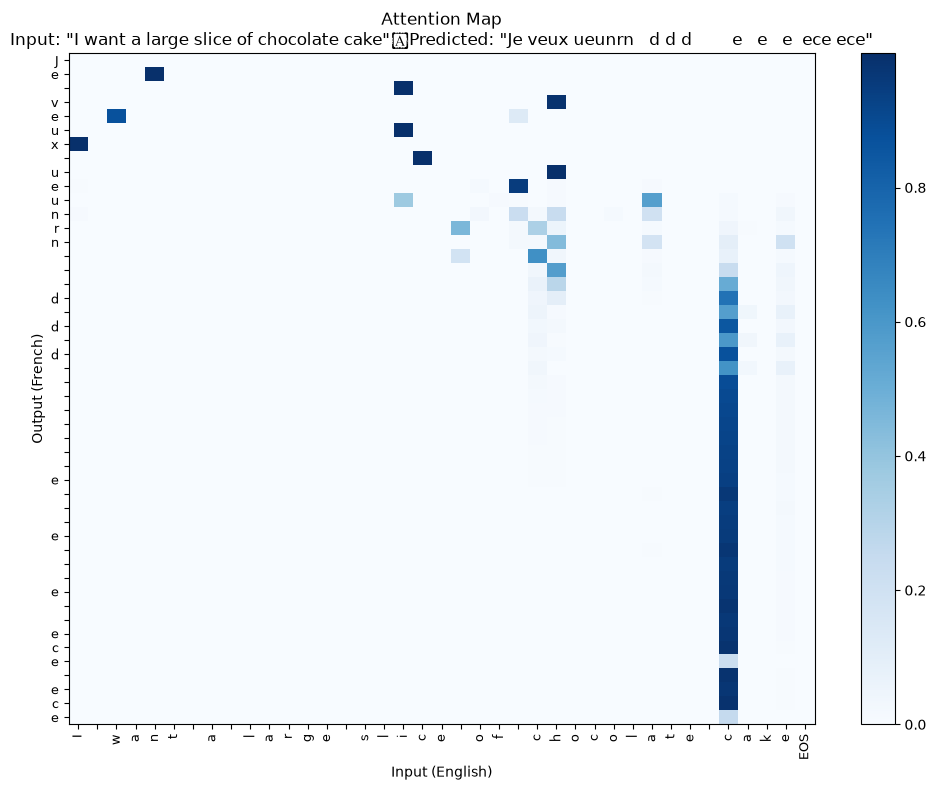

Input: I want a large slice of chocolate cake
Predicted: Je veux ueunrn   d d d        e   e   e  ece ece


In [ ]:
encoder = Encoder(inp_size=input_size, hidden_size=hidden_size).to(device)
decoder = AttnDecoder(hidden_size=hidden_size, out_size=output_size).to(device)

learning_rate = 0.001
encoder_optimiser = optim.Adam(encoder.parameters(), lr=learning_rate)
decoder_optimiser = optim.Adam(decoder.parameters(), lr=learning_rate)
criterion = nn.NLLLoss()

# Initialising loss variables
train_losses = []
val_losses = []

print("="*80)
print("Starting Training")
print("="*80)

# Training and Validation Loop
for epoch in range(no_of_epochs):
    # TRAINING
    encoder.train()
    decoder.train()
    total_train_loss = 0

    for input_tensor, target_tensor in train_loader:
        input_tensor = input_tensor[0].to(device)
        target_tensor = target_tensor[0].to(device)

        loss = train_attn(input_tensor, target_tensor, encoder, decoder, encoder_optimiser, decoder_optimiser, criterion)
        total_train_loss += loss
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION
    encoder.eval()
    decoder.eval()
    total_val_loss = 0

    with torch.no_grad():
        for input_tensor, target_tensor in val_loader:
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()
            input_length = input_tensor.size(0)
            target_length = target_tensor.size(0)
            loss = forward_pass_attn(input_tensor, target_tensor, encoder, decoder, criterion)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

eval_show_eg_attn(encoder, decoder, n_eg=5)
plot_loss(train_losses=train_losses, val_losses=val_losses, title="Part 2: GRU Encoder-Decoder (with Attention) Loss Curves", path=f'{out_path}/data/attention_loss_curves')

# Get first 2 sentences from val set
val_sentences = []
for i, (input, target) in enumerate(val_loader):
    inp_str = ''.join([idx_to_chars[idx.item()] for idx in input[0] if idx.item() not in (SOS_token, EOS_token)])
    val_sentences.append(inp_str)
    
    if i == 2:
        break

# Plot attention maps for each
for i, sentence in enumerate(val_sentences):
    plot_attention_map(encoder, decoder, sentence, path=f'{out_path}/data/attn_map_{i+1}')